# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## 1) Load required libraries and data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [28]:
# The data is coupled to my drive and mounted to be used by colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

#url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
#df = pd.read_csv(url)
data='/content/drive/MyDrive/Applied-AI-in-Transportation-main/Applied-AI-in-Transportation-main/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(data)
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [30]:
# Inspect the values in each column to verify if they are normalized
# After check the values are convrted into categorical and normalizeed
print(df['season'].unique())
print(df['yr'].unique())
print(df['mnth'].unique())
print(df['hr'].unique())
print(df['holiday'].unique())
print(df['weekday'].unique())
print(df['workingday'].unique())
print(df['weathersit'].unique())
# to know the range of tese coluns in the df, range() can not be used at it is
#not a pandeas series method, but instead let me use the min() and max() function instead
#temp	atemp	hum	windspeed
print(f"range of tem is: {df['temp'].min()} - {df['temp'].max()}")
print(f"range of atem is: {df['atemp'].min()} - {df['atemp'].max()}")
print(f"range of humudity is: {df['hum'].min()} - {df['hum'].max()}")
print(f"range of windspeed is: {df['windspeed'].min()} - {df['windspeed'].max()}")

[1 2 3 4]
[0 1]
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[0 1]
[6 0 1 2 3 4 5]
[0 1]
[1 2 3 4]
range of tem is: 0.02 - 1.0
range of atem is: 0.0 - 1.0
range of humudity is: 0.0 - 1.0
range of windspeed is: 0.0 - 0.8507


- So I can deduce that the data for all columns are normalized so that one feature will not dominate the other. But I need to remove some columns  to avoid data leakage and  inflating the model performance, so the next step is to process the data and fetaure engineering, beofre splitting the data.

In [31]:
df.shape

(17379, 17)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## 2) Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


### Data Processing and Feature Engineering Steps

1. Remove irrelevant/leaking features like, `instant`, `casual`, `registered`, and `dteday` column.
2. Apply one-hot encoding to `season`, `mnth`, `hr`, `weekday`, `weathersit`, `holiday`, `workingday`, and `yr`
 - This converts categorical integers into binary columns, which is essential for models like linear regression and often beneficial for tree-based models.
3.  Display the shape of the processed training and testing sets for verifications.

In [33]:
# Drop irrelevant columns and prevent data leakage
drop_columns = ['instant', 'casual', 'registered', 'dteday']
df_cleaned=df.drop(columns=drop_columns)

# Identify categorical features with multiple categories
# (yr, holiday, and workingday are already 0/1 binary, so we can leave them as is)
categorical_features = [
    'season', 'mnth', 'hr', 'weekday', 'weathersit'
]

# Apply one-hot encoding before splitting the data to ensure the training abd testing
# datasets have same columns, (otherwise model will crash)
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_features, drop_first=True)

print(f"shape of the encoded dataframe is:{df_encoded.shape}")

shape of the encoded dataframe is:(17379, 54)


## 3) Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [45]:
df_cleaned.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [50]:
# Train/Test and scaling

target ='cnt'

X = df_encoded.drop(columns=[target])
y = df_encoded[target].astype(float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling the data
# While Linear regrssion requires a continous features to be scaled, but not XGBosst
contineous_features=['temp', 'atemp', 'hum', 'windspeed']

scaler=StandardScaler()

X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()

X_train_scaled[contineous_features]=scaler.fit_transform(X_train[contineous_features])
X_test_scaled[contineous_features]=scaler.transform(X_test[contineous_features])
print(X_train_scaled.shape)
print(X_test_scaled.shape)


(13903, 53)
(3476, 53)


In [47]:
"""
# plot the histogram for the count of the bikes per time per hour or day, use the df['cnt']
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
sns.histplot(x=df['cnt'])
#plt.hist(df['cnt'], bins=10, color='blue')
"""

"\n# plot the histogram for the count of the bikes per time per hour or day, use the df['cnt']\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nsns.set()\nsns.histplot(x=df['cnt'])\n#plt.hist(df['cnt'], bins=10, color='blue')\n"

In [48]:
# let me also use the pairplot() function of the seaborn libraryb and try to see the correlation between the features
#sns.pairplot(X_train_processed)

## 4) Hyperparameter optimization using XGBoost
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [52]:
# Initialize the XGBoost
xgb_model=xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# define the grid of parameters to test
param_grid={
    'n_estimators':[100,200], # number of trees
    'learning_rate':[0.1],    # Step size
    'max_depth':[4,6]         # Depth of trees

}

# run grid serach
grid_search=GridSearchCV(estimator=xgb_model,
                         param_grid=param_grid,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1,  # use all computer processers
                         cv=3, # 3-fold cross validation
                         verbose=1)

# Fit the data using the unscaled data
grid_search.fit(X_train, y_train)
best_xgb_model=grid_search.best_estimator_
print(best_xgb_model)
print(grid_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}


## 5) Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [54]:
# TRAIN THE LINEAR REGRSSION MODEL
# I use the scaled data to train the model here
lr_model=LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

## 6) Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [55]:
# MAKE A PREDICTION FOR BOTH THE LINEAR REGRESSION AND XGBOOST MODELS
y_pred_lr=lr_model.predict(X_test_scaled)
y_pred_xgb=best_xgb_model.predict(X_test)

In [56]:
# EVALUATE THE METRICS
# For the linear model
lr_mse=mean_squared_error(y_test, y_pred_lr)
lr_r2=r2_score(y_test, y_pred_lr)
lr_rmse=root_mean_squared_error(y_test, y_pred_lr)

# For the XGB model
xgb_mse=mean_squared_error(y_test, y_pred_xgb)
xgb_r2=r2_score(y_test,y_pred_xgb)
xgb_rmse=root_mean_squared_error(y_test, y_pred_xgb)

# DISPLAY THE EVALAUTIONS
print("\n---EVALUATION METRICS---")
print(f"Linear Regression: MSE={lr_mse:.2f}, R2={lr_r2:.2f}, RMSE={lr_rmse:.2f}")
print(f"XGBoost: MSE={xgb_mse:.2f}, R2={xgb_r2:.2f}, RMSE={xgb_rmse:.2f}")


---EVALUATION METRICS---
Linear Regression: MSE=10089.39, R2=0.68, RMSE=100.45
XGBoost: MSE=2463.96, R2=0.92, RMSE=49.64


## 7) Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

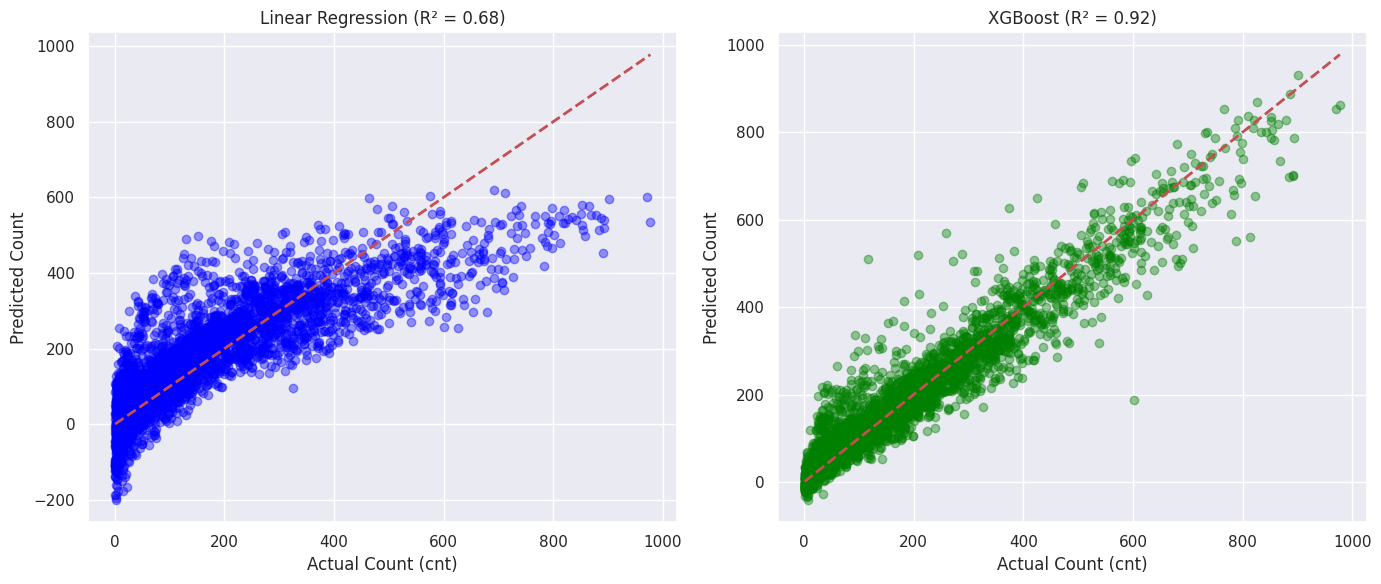

In [57]:
#Set up the Figure and its Size
plt.figure(figsize=(14, 6))

# Linear Regression Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Count (cnt)')
plt.ylabel('Predicted Count')
plt.title(f'Linear Regression (R² = {lr_r2:.2f})')

# XGBoost Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_xgb, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Count (cnt)')
plt.ylabel('Predicted Count')
plt.title(f'XGBoost (R² = {xgb_r2:.2f})')

plt.tight_layout()
plt.show()